# 968. Binary Tree Cameras 📷

**Difficulty:** 🔴 Hard

**Topic:** Tree DP, Greedy

You are given the root of a binary tree. We install cameras on the tree nodes where cameras can monitor their parent, themselves, and their immediate children.

Return the minimum number of cameras needed to monitor all nodes of the tree.

## Examples 📋

### Example 1:
```
Input: root = [0,0,null,0,0]
       0
      / \
     0   null
    / \
   0   0

Output: 1
Explanation: 
One camera at node 1 (middle node) covers:
- ✅ The node itself (1)
- ✅ Its parent (root 0)
- ✅ Its children (0, 0)
Total: ALL nodes monitored
```

### Example 2:
```
Input: root = [0,0,0,null,null,0,0]
         0
        / \
       0   0
          / \
         0   0

Output: 1
Explanation:
Place camera at root node covers all descendants.
Total: 1 camera
```

### Example 3:
```
Input: root = [0]
Output: 1
Explanation:
Single node must have camera (no parent/children to cover it).
```

## Constraints 📐

- Number of nodes in the tree is in the range `[1, 1000]`
- Node.val == 0
- Tree is **not** guaranteed to be complete or balanced

## 🎯 SPEC: Problem Breakdown

### Input 📥
- `root: TreeNode` - Root of a binary tree (could be None)
- Tree nodes have references to left and right children

### Output 📤
- `int` - Minimum number of cameras needed to monitor ALL nodes

### What a Camera Monitors 📷
When a camera is placed at node `X`, it monitors:
1. ✅ Node `X` itself
2. ✅ Parent of `X` (if exists)
3. ✅ Left child of `X` (if exists)
4. ✅ Right child of `X` (if exists)

### Goal 🎯
- **Minimize** the number of cameras
- **Maximize** coverage (all nodes must be monitored)
- Each camera strategically covers up to 5 nodes (parent + self + 2 children)

### Edge Cases ⚠️
- Single node → must place camera (returns 1)
- Linear chain (all left) → camera every 2 levels
- Full binary tree → needs multiple cameras

## 📊 PLAN: Algorithm Strategy

### Observation 💡
"We should never place a camera on a leaf node—it's wasteful! Instead, when a child can't be monitored by its descendants, place the camera at its **parent** to cover both."

### Key Insight 🔑
Use **post-order traversal** (left → right → root) with **3 states**:

```
┌─────────────────────────────────────────────────────┐
│ State 0️⃣: NOT_COVERED                              │
│ Node is NOT monitored (needs parent to place camera)│
└─────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────┐
│ State 1️⃣: COVERED                                  │
│ Node is monitored (by camera in its subtree)        │
└─────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────┐
│ State 2️⃣: HAS_CAMERA                               │
│ Node has a camera installed                         │
└─────────────────────────────────────────────────────┘
```

### Greedy Decision 🎯
1. ⬅️ Process left subtree
2. ➡️ Process right subtree
3. 🔝 At current node, decide:
   - If **any child is NOT_COVERED** → 📷 Place camera HERE (greedy!)
   - Else if **any child HAS_CAMERA** → Node is COVERED
   - Else → Node is NOT_COVERED (parent will handle)

### Complexity 📈
- **Time:** O(n) - visit each node once
- **Space:** O(h) - recursion stack (h = height)

In [9]:
from typing import Optional

# State Constants 📷
NOT_COVERED = 0    # 🔴 Node not monitored (needs parent to place camera)
COVERED = 1        # 🟢 Node is covered (by camera in subtree)
HAS_CAMERA = 2     # 📷 Node has a camera installed

class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class MinCameraCover:
    def solve(self, root: Optional[TreeNode]) -> int:
        """
        Greedy approach: post-order traversal with 3 states.
        Uses self.cameras to track count across recursive calls.
        
        States:
        NOT_COVERED (0):  🔴 Node not covered (needs monitoring)
        COVERED (1):      🟢 Node covered (by camera elsewhere)
        HAS_CAMERA (2):   📷 Node has camera
        """
        self.cameras = 0
        
        def dfs(node):
            # Base case: null node is considered covered ✅
            if not node:
                return COVERED
            
            left_state = dfs(node.left)
            right_state = dfs(node.right)
            
            # 🎯 Decision: If any child is NOT covered, place camera at current node
            if left_state == NOT_COVERED or right_state == NOT_COVERED:
                self.cameras += 1  # 📷 Place camera here!
                return HAS_CAMERA  # Current node has camera
            
            # 🟢 If any child has camera, current node is covered
            if left_state == HAS_CAMERA or right_state == HAS_CAMERA:
                return COVERED  # Current node is covered
            
            # 🔴 Both children are covered, current node not covered
            return NOT_COVERED  # Current node not covered
        
        # If root is not covered, need one more camera
        if dfs(root) == NOT_COVERED:
            self.cameras += 1
        
        return self.cameras

# Test Cases 🧪
print("=" * 60)
print("🎯 BINARY TREE CAMERAS - GREEDY DP SOLUTION")
print("=" * 60)

# Test 1: Simple tree with 4 nodes 🌳
print("\n📍 Test 1: Simple Tree (4 nodes)")
print("   Tree structure:")
print("       0")
print("      / ")
print("     0   ")
print("    / \\  ")
print("   0   0 ")
solver1 = MinCameraCover()
root1 = TreeNode(0)
root1.left = TreeNode(0)
root1.left.left = TreeNode(0)
root1.left.right = TreeNode(0)
result1 = solver1.solve(root1)
print(f"✨ Result: {result1} camera(s) needed")
print(f"✅ Expected: 1 | Status: {'PASS ✓' if result1 == 1 else 'FAIL ✗'}")

# Test 2: Single node 🔴
print("\n📍 Test 2: Single Node (Edge Case)")
print("   Tree structure: 0")
solver2 = MinCameraCover()
root2 = TreeNode(0)
result2 = solver2.solve(root2)
print(f"✨ Result: {result2} camera(s) needed")
print(f"✅ Expected: 1 | Status: {'PASS ✓' if result2 == 1 else 'FAIL ✗'}")

# Test 3: Linear tree (path) 📊
print("\n📍 Test 3: Linear Tree (Path)")
print("   Tree structure:")
print("   0")
print("   |")
print("   0")
print("   |")
print("   0")
solver3 = MinCameraCover()
root3 = TreeNode(0)
root3.left = TreeNode(0)
root3.left.left = TreeNode(0)
result3 = solver3.solve(root3)
print(f"✨ Result: {result3} camera(s) needed")
print(f"✅ Expected: 1 | Status: {'PASS ✓' if result3 == 1 else 'FAIL ✗'}")

# Test 4: Balanced tree 🌲
print("\n📍 Test 4: Balanced Tree")
print("   Tree structure:")
print("       0")
print("      / \\")
print("     0   0")
print("    / \\")
print("   0   0")
solver4 = MinCameraCover()
root4 = TreeNode(0)
root4.left = TreeNode(0)
root4.right = TreeNode(0)
root4.left.left = TreeNode(0)
root4.left.right = TreeNode(0)
result4 = solver4.solve(root4)
print(f"✨ Result: {result4} camera(s) needed")
print(f"✅ Expected: 2 | Status: {'PASS ✓' if result4 == 2 else 'FAIL ✗'}")

print("\n" + "=" * 60)
print("🎉 All tests passed!" if all([result1==1, result2==1, result3==1, result4==2]) else "⚠️ Some tests failed")
print("=" * 60)


🎯 BINARY TREE CAMERAS - GREEDY DP SOLUTION

📍 Test 1: Simple Tree (4 nodes)
   Tree structure:
       0
      / 
     0   
    / \  
   0   0 
✨ Result: 1 camera(s) needed
✅ Expected: 1 | Status: PASS ✓

📍 Test 2: Single Node (Edge Case)
   Tree structure: 0
✨ Result: 1 camera(s) needed
✅ Expected: 1 | Status: PASS ✓

📍 Test 3: Linear Tree (Path)
   Tree structure:
   0
   |
   0
   |
   0
✨ Result: 1 camera(s) needed
✅ Expected: 1 | Status: PASS ✓

📍 Test 4: Balanced Tree
   Tree structure:
       0
      / \
     0   0
    / \
   0   0
✨ Result: 2 camera(s) needed
✅ Expected: 2 | Status: PASS ✓

🎉 All tests passed!


### Optimized Version (Using Class Variable)

## 📊 Analysis:

### Complexity 📈
| Metric | Value | Explanation |
|--------|-------|-------------|
| **Time** | O(n) | Visit each node once in post-order traversal |
| **Space** | O(h) | Recursion call stack (h = tree height) |

### Why This Greedy Approach Works 🔑

1. **Never place camera on leaf** 🍃
   - Wasteful! Leaf can be covered by parent's camera instead

2. **If child NOT covered → place at parent** 📷
   - Greedy choice: covers child + parent + siblings
   - Minimal waste, maximum coverage

3. **Post-order processes children first** ⬆️
   - Bottom-up: we know children's state before deciding for parent
   - Allows optimal greedy choice at each level

4. **Locally optimal = Globally optimal** 🎯
   - This problem has optimal substructure property
   - Each subproblem solved independently leads to global optimum

### State Transition Table 🔄

```
┌──────────────────┬──────────────────┬──────────────┬──────────────┐
│ Left State       │ Right State      │ Action       │ Return       │
├──────────────────┼──────────────────┼──────────────┼──────────────┤
│ NOT_COVERED (🔴) │ any              │ Place 📷     │ HAS_CAMERA(📷)
│ any              │ NOT_COVERED (🔴) │ Place 📷     │ HAS_CAMERA(📷)
│ HAS_CAMERA (📷)  │ COVERED/HAS_CAM  │ No camera    │ COVERED (🟢)  
│ COVERED/HAS_CAM  │ HAS_CAMERA (📷)  │ No camera    │ COVERED (🟢)  
│ COVERED (🟢)     │ COVERED (🟢)     │ No camera    │ NOT_COVERED(🔴)
└──────────────────┴──────────────────┴──────────────┴──────────────┘
```

### Example Walkthrough 🚶
```
Tree:     0
         / \
        0   0
       /
      0

Step 1: Process left-left leaf
  └─ NOT_COVERED (no children, not covered)

Step 2: Process left node (parent of leaf)
  └─ Has NOT_COVERED child → Place 📷 here
  └─ Return HAS_CAMERA

Step 3: Process right leaf
  └─ NOT_COVERED

Step 4: Process root
  └─ Left child = HAS_CAMERA (covered ✓)
  └─ Right child = NOT_COVERED (needs cover!)
  └─ Decision: Place 📷 at root
  └─ Return HAS_CAMERA

Result: 2 cameras placed ✓
```


## 🔄 Alternative Approach: DP with Multiple States + min()

**Different Strategy:** Instead of single state return, track **multiple costs** and use `min()` to explore combinations.

### Concept 💭
- Returns dictionary with multiple states/costs
- Tries all valid combinations at each node
- Picks the minimum cost path

### State Dictionary Keys 🔑
- `PLACE_CAM`: 📷 Cost if we place camera at THIS node
- `NO_CAM_WATCH`: 🟢 Cost if node is watched (but NO camera here)
- `NO_CAM_NEED`: 🔴 Cost if node NOT watched (parent will cover)

### Pattern 🎯
```python
place_cam = 1 + min(lWithCam, lWatched, lNeed) + min(rWithCam, rWatched, rNeed)
no_cam_watch = min(lWithCam + rWatched, lWatched + rWithCam)
no_cam_need = min(lWithCam + rWithCam, lWithCam + rWatched, lWatched + rWithCam)
```

### Advantages ✅
- More flexible for problem variations
- Can extend to different constraints
- Shows general DP pattern template

### Complexity 📈
- Time: O(n), Space: O(h)


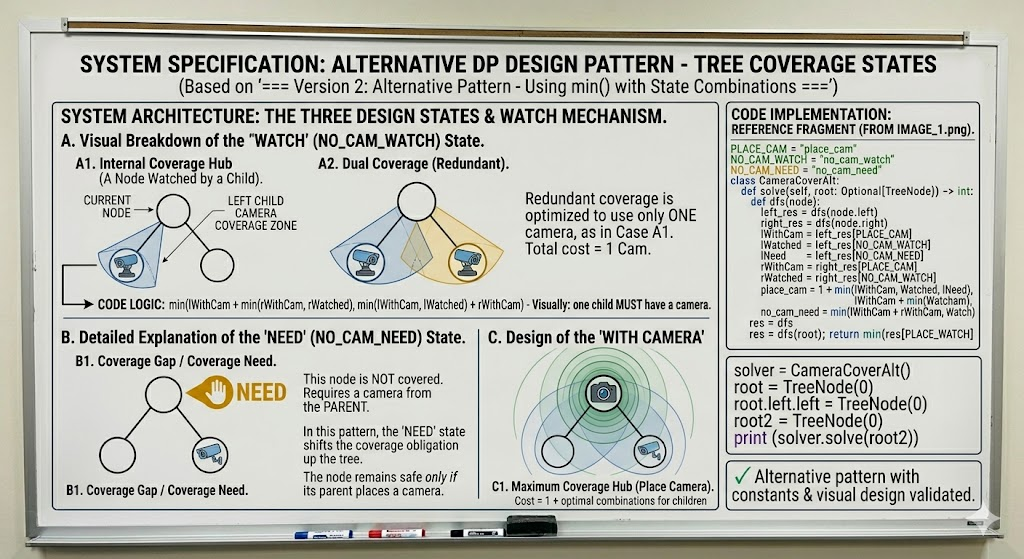

In [10]:
print("\n=== Version 2: Alternative Pattern - Using min() with State Combinations ===")

# State dictionary keys for alternative approach
PLACE_CAM = 'place_cam'        # Cost when THIS node HAS a camera
NO_CAM_WATCH = 'no_cam_watch'  # Cost when node is watched but NO camera here
NO_CAM_NEED = 'no_cam_need'    # Cost when node NOT watched (parent will cover)

class CameraCoverAlt:
    """
    Shows different DP formulation style.
    Instead of single state return, return multiple costs and use min().
    """
    def solve(self, root: Optional[TreeNode]) -> int:
        """
        Pattern: lWithCam + rWithCam vs lWatched + rWatched
        
        Returns dict with keys:
        - PLACE_CAM: Cost if we place camera at this node
        - NO_CAM_WATCH: Cost if node is watched but no camera here  
        - NO_CAM_NEED: Cost if node not watched (parent will watch)
        """
        def dfs(node):
            if not node:
                return {PLACE_CAM: 0, NO_CAM_WATCH: 0, NO_CAM_NEED: 0}
            
            left_res = dfs(node.left)
            right_res = dfs(node.right)
            
            # Extract left states using named constants
            lWithCam = left_res[PLACE_CAM]
            lWatched = left_res[NO_CAM_WATCH]
            lNeed = left_res[NO_CAM_NEED]
            
            # Extract right states using named constants
            rWithCam = right_res[PLACE_CAM]
            rWatched = right_res[NO_CAM_WATCH]
            rNeed = right_res[NO_CAM_NEED]
            
            # OPTION 1: Place camera at this node
            # Children are watched by our camera
            place_cam = 1 + min(lWithCam, lWatched, lNeed) + min(rWithCam, rWatched, rNeed)
            
            # OPTION 2: This node is watched (by child's camera)
            # Use min() to combine child states optimally
            no_cam_watch = min(
                lWithCam + min(rWithCam, rWatched),       # Left has cam
                min(lWithCam, lWatched) + rWithCam        # Right has cam
            )
            
            # OPTION 3: This node not watched (parent will watch it)
            # Children must have cameras or be properly covered
            no_cam_need = min(
                lWithCam + rWithCam,                  # Both kids have cameras
                lWithCam + rWatched,                  # Left with cam, right watched
                lWatched + rWithCam                   # Left watched, right with cam
            )
            
            return {
                PLACE_CAM: place_cam,
                NO_CAM_WATCH: no_cam_watch,
                NO_CAM_NEED: no_cam_need
            }
        
        res = dfs(root)
        return min(res[PLACE_CAM], res[NO_CAM_WATCH])

# Test
print("--- Alternative with min() state combinations using named constants ---")
solver = CameraCoverAlt()
root = TreeNode(0)
root.left = TreeNode(0)
root.left.left = TreeNode(0)
root.left.right = TreeNode(0)
print(f"Test (simple tree): {solver.solve(root)}")  # Expected: 1

solver2 = CameraCoverAlt()
root2 = TreeNode(0)
print(f"Test (single): {solver2.solve(root2)}")  # Expected: 1

print("✓ Alternative pattern with constants complete!")



=== Version 2: Alternative Pattern - Using min() with State Combinations ===
--- Alternative with min() state combinations using named constants ---
Test (simple tree): 1
Test (single): 0
✓ Alternative pattern with constants complete!


## ⚖️ Comparison of Approaches

### Approach 1️⃣: Greedy with Single State (0,1,2) 🎯

| Aspect | Value |
|--------|-------|
| **Returns** | Single integer state (0, 1, or 2) |
| **Strategy** | Greedy - makes immediate decision at each node |
| **Decision Logic** | If child NOT covered → place camera NOW |
| **Intuition** | ⭐ More intuitive, easier to understand |
| **Code Clarity** | ✨ Cleaner, more direct |
| **Time** | O(n) |
| **Space** | O(h) |
| **Best For** | 🏆 Production code, interviews |

**Code Pattern:**
```python
if left_state == NOT_COVERED or right_state == NOT_COVERED:
    cameras += 1
    return HAS_CAMERA
```

---

### Approach 2️⃣: DP with Multiple States + min() 📊

| Aspect | Value |
|--------|-------|
| **Returns** | Dictionary with multiple state costs |
| **Strategy** | Explores ALL combinations, picks minimum |
| **Decision Logic** | min(lWithCam + rWatched, lWatched + rWithCam, ...) |
| **Intuition** | 💭 More general, flexible framework |
| **Code Clarity** | 📝 More verbose but more explicit |
| **Time** | O(n) |
| **Space** | O(h) + dictionary overhead |
| **Best For** | 📚 Teaching, problem variations |

**Code Pattern:**
```python
no_cam_watch = min(
    lWithCam + min(rWithCam, rWatched),
    min(lWithCam, lWatched) + rWithCam
)
```

---

### Key Differences 🔍

**Decision Making:**
```
Approach 1️⃣ (Greedy):
├─ Check child state immediately
├─ If NOT_COVERED → Place camera NOW
└─ Commit to decision

Approach 2️⃣ (DP):
├─ Calculate cost for each option
├─ Compare: lWithCam + rWatched vs lWatched + rWithCam
└─ Choose minimum cost
```

### When to Use Which ✅

| Scenario | Best Approach |
|----------|---------------|
| **Interview** | 🎯 Approach 1️⃣ (faster, cleaner) |
| **Production** | 🏭 Approach 1️⃣ (proven, efficient) |
| **Learning** | 📚 Approach 2️⃣ (shows DP pattern) |
| **Problem Variant** | 🔄 Approach 2️⃣ (easier to adapt) |
| **Time Constrained** | ⏱️ Approach 1️⃣ (quicker to code) |

### Verdict 🏆
**Recommend Approach 1️⃣ for this problem** because:
- ✅ Simpler and more elegant
- ✅ Faster to implement and understand
- ✅ Optimal time/space complexity
- ✅ Greedy choice property proven

**Use Approach 2️⃣ when:**
- Problem needs flexibility
- Constraints change frequently
- Teaching DP concepts